In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

# Load CSV  for benin-malanville
df = pd.read_csv("../data/benin-malanville.csv")
print("Shape:", df.shape)
print(df.info())
print(df.describe())
print(df.isna().sum())
# Only fill NaN for numeric columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# If you want to drop columns that are all NaN, like 'Comments':
df = df.drop(columns=['Comments'])


Shape: (525600, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525600 entries, 0 to 525599
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Timestamp      525600 non-null  object 
 1   GHI            525600 non-null  float64
 2   DNI            525600 non-null  float64
 3   DHI            525600 non-null  float64
 4   ModA           525600 non-null  float64
 5   ModB           525600 non-null  float64
 6   Tamb           525600 non-null  float64
 7   RH             525600 non-null  float64
 8   WS             525600 non-null  float64
 9   WSgust         525600 non-null  float64
 10  WSstdev        525600 non-null  float64
 11  WD             525600 non-null  float64
 12  WDstdev        525600 non-null  float64
 13  BP             525600 non-null  int64  
 14  Cleaning       525600 non-null  int64  
 15  Precipitation  525600 non-null  float64
 16  TModA          525600 non-null  float64
 17  TModB    

In [2]:
# 5️⃣ Detect outliers
df['z_GHI'] = zscore(df['GHI'])
df = df[df['z_GHI'].abs() < 3]
print(df)
df.drop(columns=['z_GHI'], inplace=True)

               Timestamp  GHI  DNI  DHI  ModA  ModB  Tamb    RH   WS  WSgust  \
0       2021-08-09 00:01 -1.2 -0.2 -1.1   0.0   0.0  26.2  93.4  0.0     0.4   
1       2021-08-09 00:02 -1.1 -0.2 -1.1   0.0   0.0  26.2  93.6  0.0     0.0   
2       2021-08-09 00:03 -1.1 -0.2 -1.1   0.0   0.0  26.2  93.7  0.3     1.1   
3       2021-08-09 00:04 -1.1 -0.1 -1.0   0.0   0.0  26.2  93.3  0.2     0.7   
4       2021-08-09 00:05 -1.0 -0.1 -1.0   0.0   0.0  26.2  93.3  0.1     0.7   
...                  ...  ...  ...  ...   ...   ...   ...   ...  ...     ...   
525595  2022-08-08 23:56 -5.5 -0.1 -5.9   0.0   0.0  23.1  98.3  0.3     1.1   
525596  2022-08-08 23:57 -5.5 -0.1 -5.8   0.0   0.0  23.1  98.3  0.2     0.7   
525597  2022-08-08 23:58 -5.5 -0.1 -5.8   0.0   0.0  23.1  98.4  0.6     1.1   
525598  2022-08-08 23:59 -5.5 -0.1 -5.8   0.0   0.0  23.1  98.3  0.9     1.3   
525599  2022-08-09 00:00 -5.5 -0.1 -5.7   0.0   0.0  23.1  98.3  1.2     1.6   

        WSstdev     WD  WDstdev   BP  C

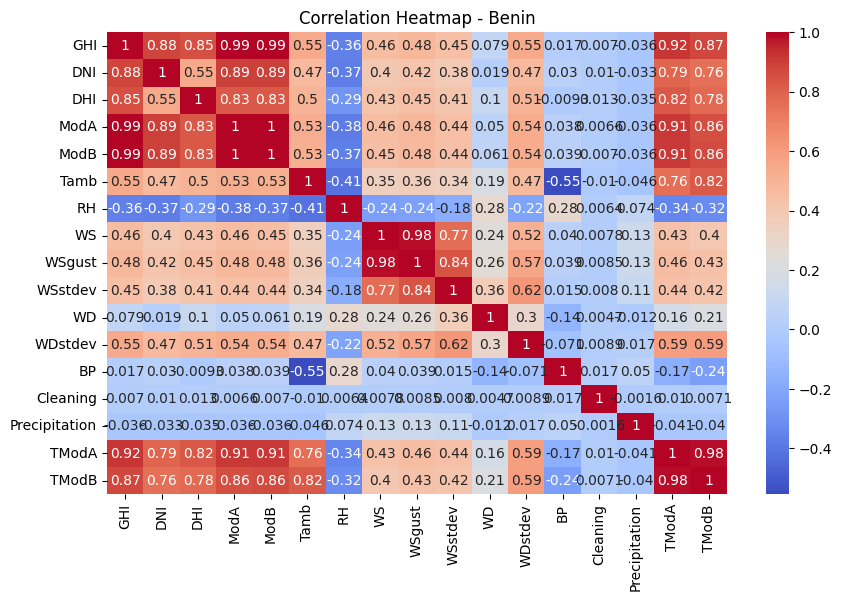

                    GHI       DNI       DHI      ModA      ModB      Tamb  \
GHI            1.000000  0.882294  0.849839  0.994443  0.994866  0.547777   
DNI            0.882294  1.000000  0.546207  0.891940  0.891935  0.467656   
DHI            0.849839  0.546207  1.000000  0.829749  0.827710  0.504044   
ModA           0.994443  0.891940  0.829749  1.000000  0.998744  0.527066   
ModB           0.994866  0.891935  0.827710  0.998744  1.000000  0.525590   
Tamb           0.547777  0.467656  0.504044  0.527066  0.525590  1.000000   
RH            -0.360589 -0.373839 -0.285371 -0.383722 -0.366251 -0.414881   
WS             0.457554  0.397152  0.427049  0.458654  0.450307  0.347186   
WSgust         0.484347  0.419516  0.450986  0.484596  0.476561  0.362397   
WSstdev        0.446622  0.383284  0.414713  0.443535  0.438602  0.342409   
WD             0.079439  0.018623  0.102594  0.050034  0.061248  0.188067   
WDstdev        0.547408  0.471180  0.505991  0.538460  0.538468  0.469862   

In [3]:
# Select only numeric columns for the correlation heatmap
numeric_cols = df.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(10,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap - Benin')
plt.show()
# Get and print the full correlation matrix for all numeric columns
corr_matrix = numeric_cols.corr()
print(corr_matrix)


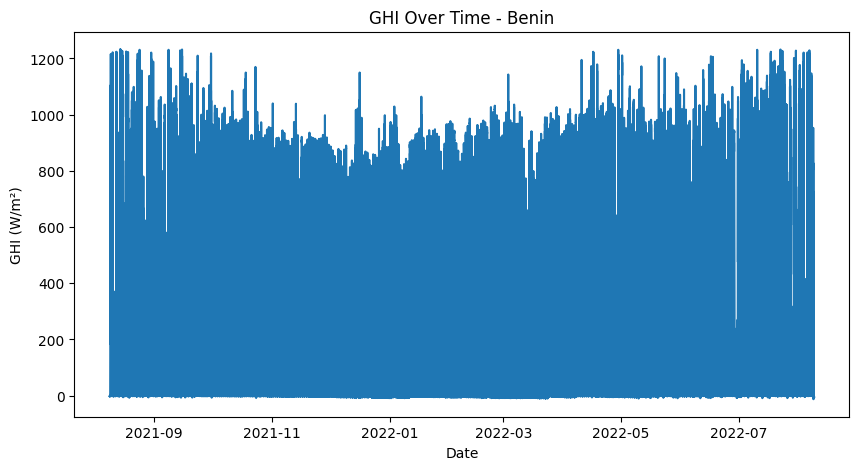

In [4]:
# 8️⃣ Plot GHI over time
plt.figure(figsize=(10,5))
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
plt.plot(df['Timestamp'], df['GHI'])
plt.title('GHI Over Time - Benin')
plt.xlabel('Date')
plt.ylabel('GHI (W/m²)')
plt.show()

# 9️⃣ Export cleaned data
df.to_csv('../data/benin_clean.csv', index=False)

In [5]:
# Get numeric correlation matrix
corr_matrix = numeric_cols.corr()

# Calculate average absolute correlation for each variable (excluding self, the diagonal)
average_corr = corr_matrix.apply(lambda row: (row.drop(row.name).abs().mean()), axis=1)
print(average_corr)


GHI              0.531233
DNI              0.460134
DHI              0.462803
ModA             0.527909
ModB             0.526693
Tamb             0.430735
RH               0.273276
WS               0.393532
WSgust           0.414521
WSstdev          0.389336
WD               0.154229
WDstdev          0.411246
BP               0.109350
Cleaning         0.008360
Precipitation    0.051097
TModA            0.546719
TModB            0.537317
dtype: float64
